In [15]:
# Ensure the project root is on PYTHONPATH when running from notebooks/
from pathlib import Path
import sys
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))



# Robustness + THD (Switching Window)

This notebook runs a short switching simulation to compute current THD at a representative operating point, and reproduces the **Lf variation** test (30 mH vs 15 mH).


In [16]:
from pathlib import Path

for p in Path("..").rglob("thd_summary.json"):
    print(p.resolve())


C:\Users\asus\OneDrive\Desktop\CONF. 6 ISAA 2026\hybrid_acdc_ofo_nn_project_fixed_v2\results\thd\thd_summary.json


In [17]:
import subprocess
import sys

cmd = [
    sys.executable, "-m", "hybrid_acdc", "thd",
    "--config", "../config/system.yaml",
    "--pid_ref", "../results/pid_ref/pid_ref.json",
    "--controller", "ofo_nn",
    "--out", "../results/thd",
    "--f_sw", "10000",
    "--dt_emt", "2e-6",
    "--t_emt", "0.25",
]

print("Running:", " ".join(cmd))
res = subprocess.run(cmd, capture_output=True, text=True)
print(res.stdout)
print(res.stderr)


Running: c:\Users\asus\anaconda3\python.exe -m hybrid_acdc thd --config ../config/system.yaml --pid_ref ../results/pid_ref/pid_ref.json --controller ofo_nn --out ../results/thd --f_sw 10000 --dt_emt 2e-6 --t_emt 0.25

c:\Users\asus\anaconda3\python.exe: No module named hybrid_acdc



In [3]:
from pathlib import Path
Path("../results/thd").mkdir(parents=True, exist_ok=True)


In [ ]:
python -m hybrid_acdc thd --config config/system.yaml --pid_ref results/pid_ref/pid_ref.json --controller ofo_nn --out results/thd --f_sw 10000 --dt_emt 2e-6 --t_emt 0.25


In [4]:
import json
from pathlib import Path

summary_path = Path("../results/thd/thd_summary.json")

print("Exists:", summary_path.exists())
print("Resolved:", summary_path.resolve())

summary = json.loads(summary_path.read_text())
summary


Exists: True
Resolved: C:\Users\asus\OneDrive\Desktop\CONF. 6 ISAA 2026\hybrid_acdc_ofo_nn_project_fixed_v2\results\thd\thd_summary.json


{'operating_point': {'t_s': 120.0,
  'vdc': 850.0000000000009,
  'id1': 152.9999999999722,
  'iq1': 19.99999999999982},
 'switching': {'f_sw': 10000.0,
  'dt_emt': 2e-06,
  't_emt': 0.25,
  'Rf': 0.06,
  'L1': 0.03,
  'L2': 0.015,
  'n_harm': 40},
 'thd': {'L1': 25.634157375533444, 'L2': 22.41588287806577}}

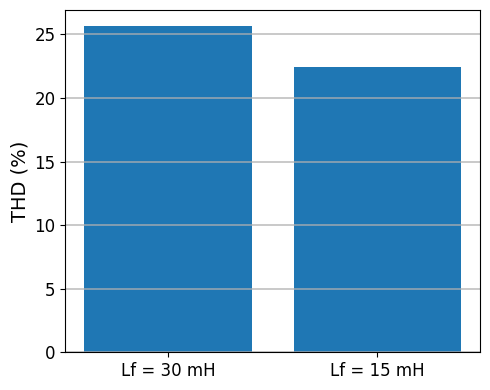

In [ ]:
import matplotlib.pyplot as plt

thd = summary['thd']
labels = ['Lf = 30 mH', 'Lf = 15 mH']
vals = [thd['L1'], thd['L2']]

plt.figure(figsize=(5, 4))
plt.bar(labels, vals)

plt.ylabel('THD (%)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, axis='y', linestyle='-', linewidth=1.5, alpha=0.9)

plt.tight_layout()
plt.savefig(
    "Fig_THD_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


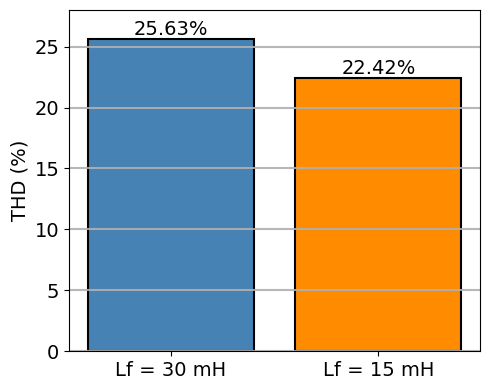

In [29]:
import matplotlib.pyplot as plt

thd = summary['thd']
labels = ['Lf = 30 mH', 'Lf = 15 mH']
vals = [thd['L1'], thd['L2']]

plt.figure(figsize=(5, 4))

bars = plt.bar(
    labels,
    vals,
    color=['steelblue', 'darkorange'],   # distinct, print-safe colors
    edgecolor='black',
    linewidth=1.5
)

plt.ylabel('THD (%)', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(0, 28)

# ---- Value labels on bars ----
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}%',
        ha='center',
        va='bottom',
        fontsize=14
    )

plt.grid(True, axis='y', linestyle='-', linewidth=1.5, alpha=0.9)

plt.tight_layout()

plt.savefig(
    "Fig_THD_Comparison.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


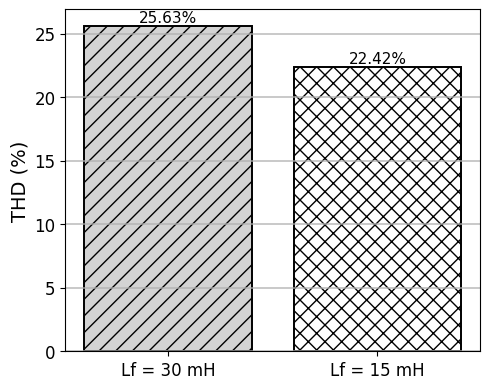

In [28]:
import matplotlib.pyplot as plt

thd = summary['thd']
labels = ['Lf = 30 mH', 'Lf = 15 mH']
vals = [thd['L1'], thd['L2']]

plt.figure(figsize=(5, 4))

bars = plt.bar(
    labels,
    vals,
    color=['lightgray', 'white'],
    edgecolor='black',
    linewidth=1.4,
    hatch=['//', 'xx']   # texture instead of strong colors
)

plt.ylabel('THD (%)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.grid(True, axis='y', linestyle='-', linewidth=1.2, alpha=0.8)

plt.tight_layout()
plt.savefig(
    "Fig_THD_Comparison_Hatched.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()
